In [ ]:
from backtest import VectorizedBacktester, GetPriceData
from long_momentum import LongOnlyMomentumSignal

# 4 hour candle

c:\Users\User\Desktop\MarginCallCapital\margincallcapital\signals\long_momentum.py:64: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()
c:\Users\User\Desktop\MarginCallCapital\margincallcapital\signals\backtest.py:201: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  asset_returns = self.prices.pct_change().fillna(0.0)


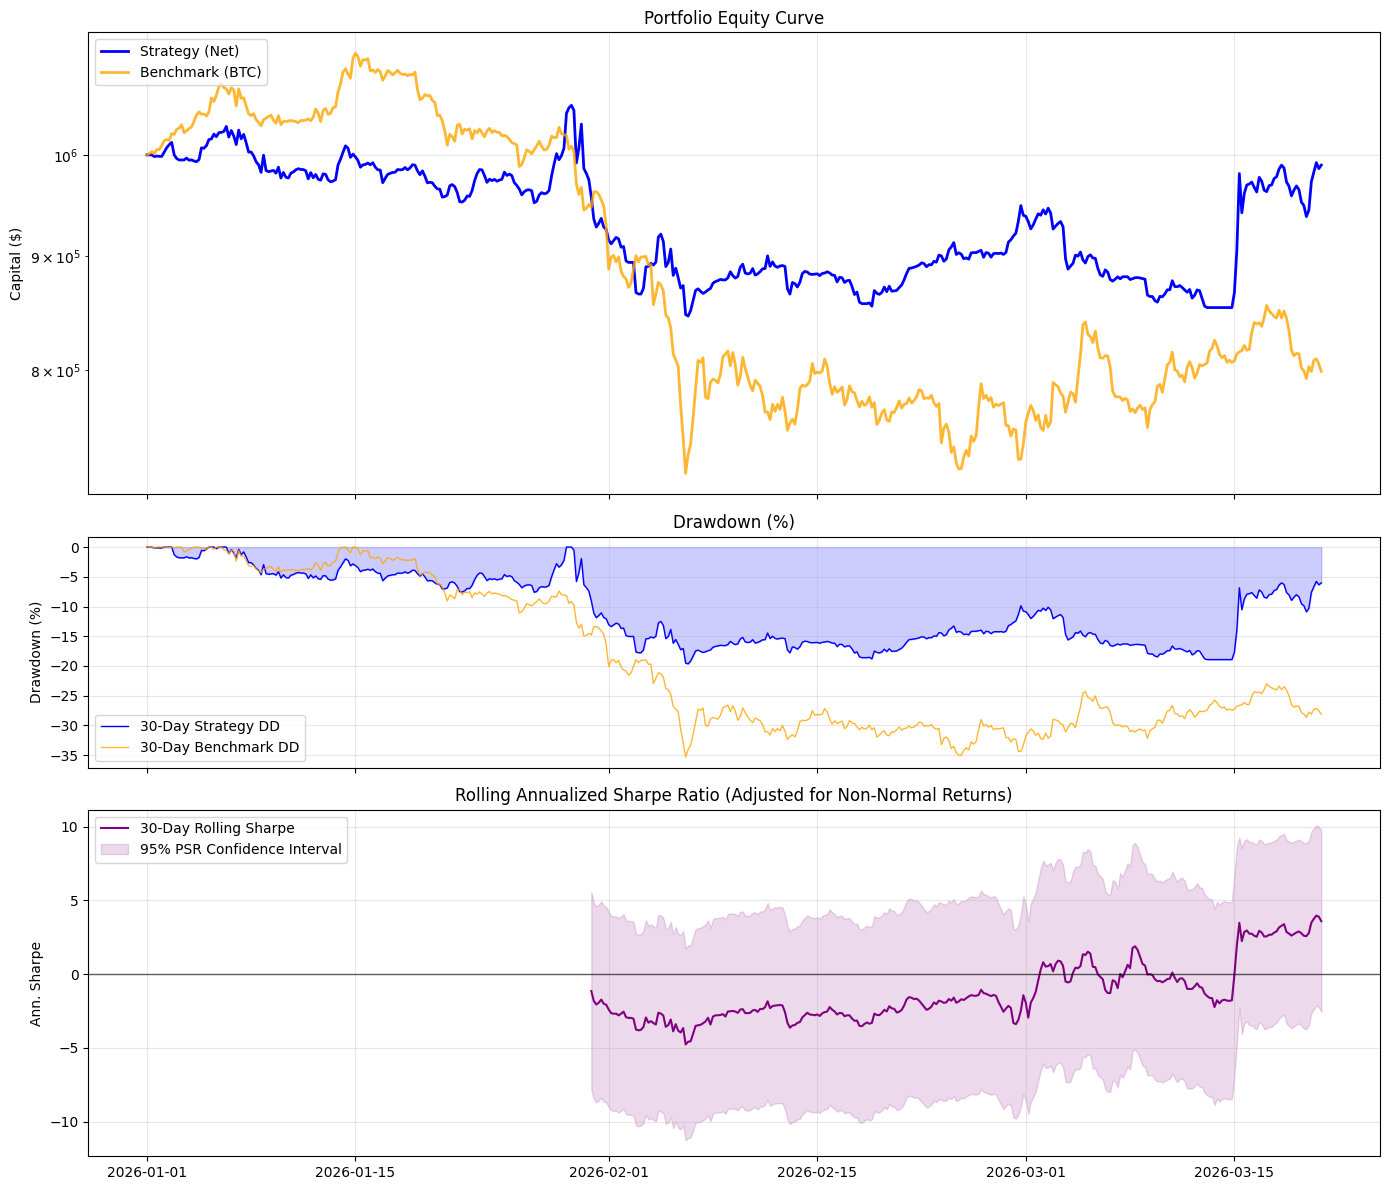

                     STRATEGY TEARSHEET                     
Metric                    |     Strategy |    Benchmark
-------------------------------------------------------
Total Return (%)          |        -1.06 |       -20.12
Ann. Return (%)           |        -4.81 |       -64.57
Ann. Volatility (%)       |        42.82 |        49.99
Max Drawdown (%)          |       -19.64 |       -35.32
Sharpe Ratio              |        -0.11 |        -1.29
Probabilistic Sharpe (%)  |        51.81 |        19.62
Sortino Ratio             |        -0.14 |        -1.68
Calmar Ratio              |        -0.24 |        -1.83
Win Rate (%)              |        52.76 |        50.11
Daily Turnover (%)        |        41.78 |         0.00

Holdings on 2026-03-20:
- CFX-USD: 14.2%
- FET-USD: 11.5%
- STO-USD: 8.5%
- TAO-USD: 10.7%
- TRX-USD: 55.1%
- CASH: 0.0%


In [15]:
signal_generator = LongOnlyMomentumSignal(fast_span=50, slow_span=200, vol_span=260, z_score_threshold=0.9, top_n=6)

# Generate the weights DataFrame
close_4h = GetPriceData(db_path='../data/ohlcv_4h.duckdb').fetch_price_data()
btc_close_4h = close_4h['BTC-USD']
target_weights = signal_generator.generate_weights(close_4h)

# Feed the prices and weights into your backtester
backtester = VectorizedBacktester(
    prices=close_4h,
    weights=target_weights,
    benchmark_prices=btc_close_4h, # Optional BTC benchmark
    fee_rate=0.001, 
    slippage=0.0005,  
    initial_capital=1e6, 
    periods_per_year=365*6,  # Adjust based on your data frequency
    start_date='2026-01-01',
    end_date='2026-03-20'
)

# Run and evaluate
backtester.run()
backtester.plot_charts()
backtester.print_tearsheet()
crash_date = '2026-03-20'

holdings = backtester.get_holdings(crash_date)

print(f"\nHoldings on {crash_date}:")
for coin, weight in holdings.items():
    print(f"- {coin}: {weight*100:.1f}%")

# If the total weight is < 100%, the remainder is your Cash position!
total_invested = sum(holdings.values())
print(f"- CASH: {(1 - total_invested)*100:.1f}%")

# 1 day candle

c:\Users\User\Desktop\MarginCallCapital\margincallcapital\signals\long_momentum.py:64: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()
c:\Users\User\Desktop\MarginCallCapital\margincallcapital\signals\backtest.py:201: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  asset_returns = self.prices.pct_change().fillna(0.0)


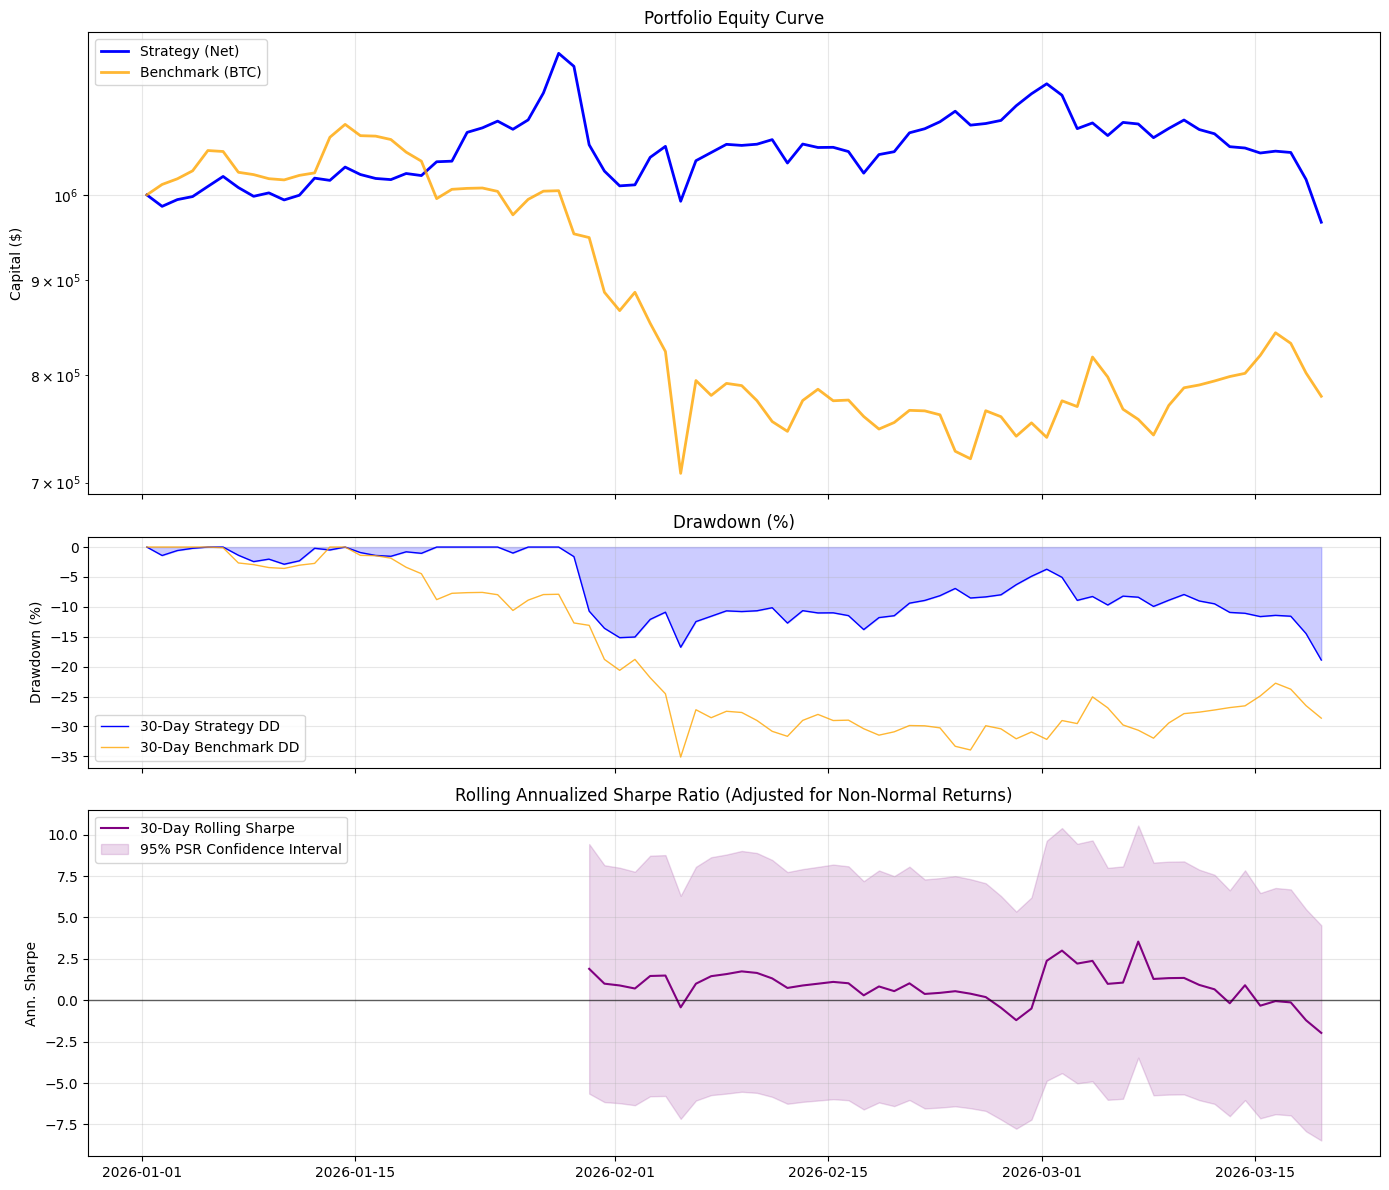

                     STRATEGY TEARSHEET                     
Metric                    |     Strategy |    Benchmark
-------------------------------------------------------
Total Return (%)          |        -3.33 |       -22.09
Ann. Return (%)           |       -14.66 |       -68.90
Ann. Volatility (%)       |        42.50 |        61.09
Max Drawdown (%)          |       -18.89 |       -35.11
Sharpe Ratio              |        -0.35 |        -1.13
Probabilistic Sharpe (%)  |        47.05 |        22.93
Sortino Ratio             |        -0.38 |        -1.51
Calmar Ratio              |        -0.78 |        -1.96
Win Rate (%)              |        55.84 |        44.16
Daily Turnover (%)        |         2.64 |         0.00
Exact timestamp not found. Showing holdings for closest prior bar: 2026-02-28 08:00:00+08:00

Holdings on 2026-03-01:
- PAXG-USD: 100.0%
- CASH: 0.0%


In [26]:
signal_generator = LongOnlyMomentumSignal(fast_span=50, slow_span=200, vol_span=260, z_score_threshold=0.9, top_n=6)

# Generate the weights DataFrame
close_1d = GetPriceData(db_path='../data/ohlcv_1d.duckdb').fetch_price_data()
btc_close_1d = close_1d['BTC-USD']
target_weights = signal_generator.generate_weights(close_1d)

# Feed the prices and weights into your backtester
backtester = VectorizedBacktester(
    prices=close_1d,
    weights=target_weights,
    benchmark_prices=btc_close_1d, # Optional BTC benchmark
    fee_rate=0.001, 
    slippage=0.0005,  
    initial_capital=1e6, 
    periods_per_year=365,  # Adjust based on your data frequency
    start_date='2026-01-01',
    end_date='2026-03-21'
)

# Run and evaluate
backtester.run()
backtester.plot_charts()
backtester.print_tearsheet()
crash_date = '2026-03-01'

holdings = backtester.get_holdings(crash_date)

print(f"\nHoldings on {crash_date}:")
for coin, weight in holdings.items():
    print(f"- {coin}: {weight*100:.1f}%")

# If the total weight is < 100%, the remainder is your Cash position!
total_invested = sum(holdings.values())
print(f"- CASH: {(1 - total_invested)*100:.1f}%")

c:\Users\User\Desktop\MarginCallCapital\margincallcapital\signals\long_momentum.py:64: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()
c:\Users\User\Desktop\MarginCallCapital\margincallcapital\signals\backtest.py:201: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  asset_returns = self.prices.pct_change().fillna(0.0)


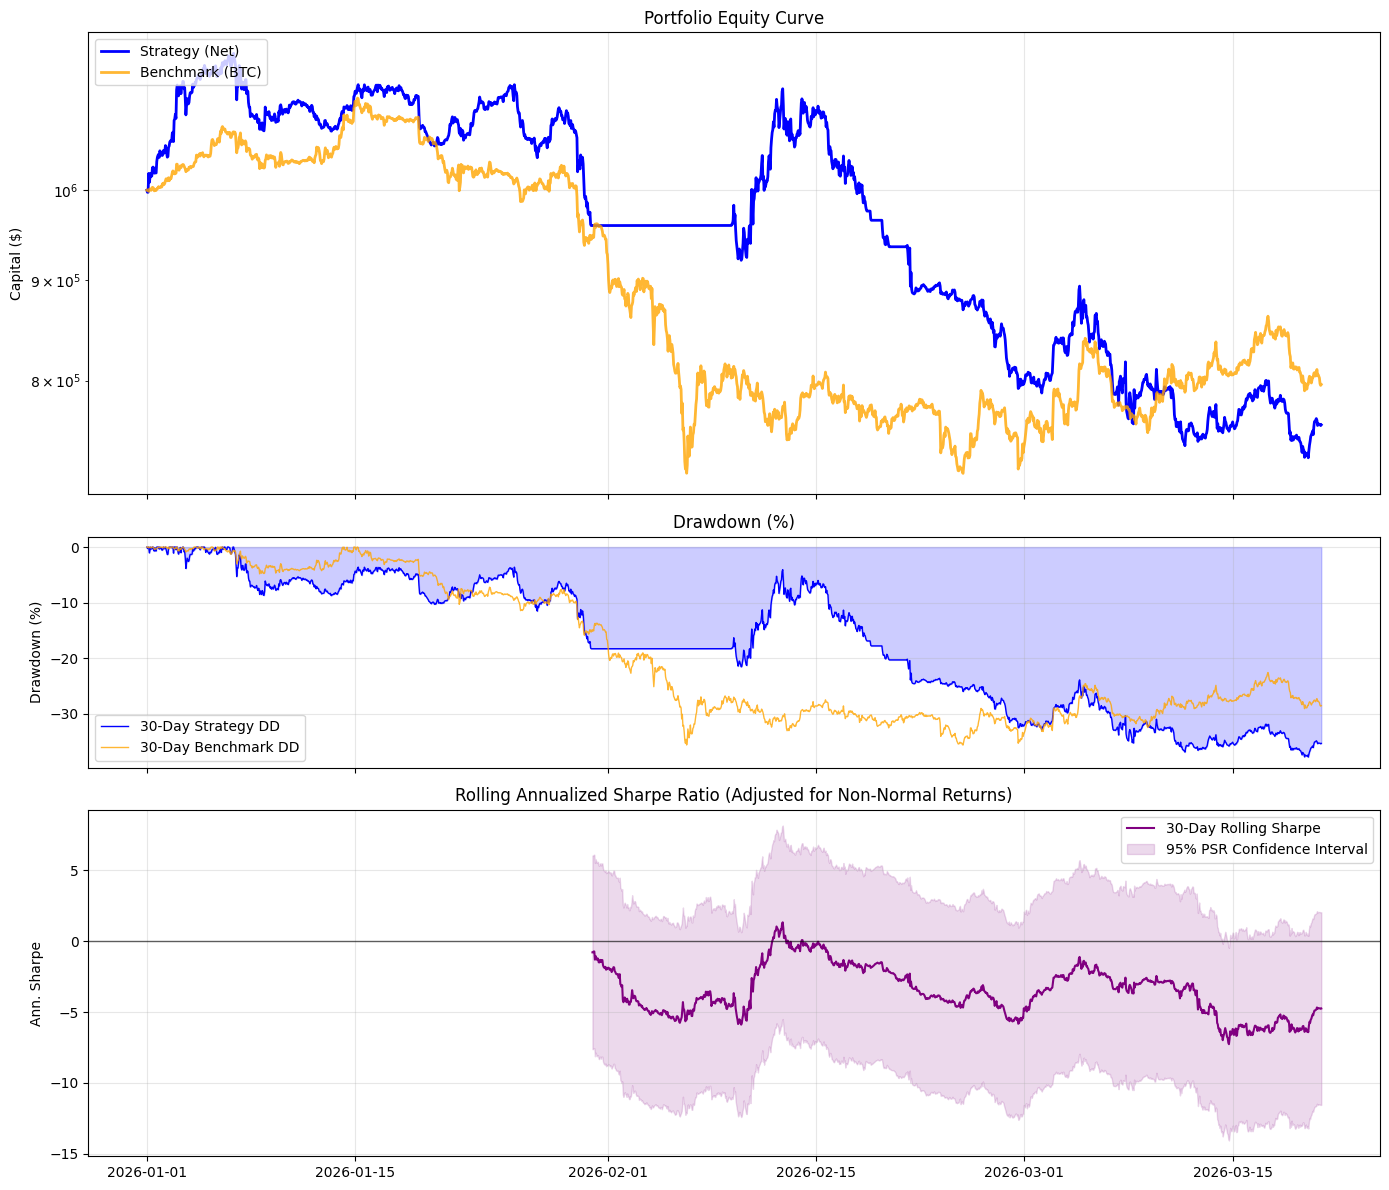

                     STRATEGY TEARSHEET                     
Metric                    |     Strategy |    Benchmark
-------------------------------------------------------
Total Return (%)          |       -24.04 |       -20.36
Ann. Return (%)           |       -71.93 |       -65.08
Ann. Volatility (%)       |        56.45 |        52.27
Max Drawdown (%)          |       -37.76 |       -35.59
Sharpe Ratio              |        -1.27 |        -1.24
Probabilistic Sharpe (%)  |        17.98 |        20.72
Sortino Ratio             |        -1.53 |        -1.63
Calmar Ratio              |        -1.91 |        -1.83
Win Rate (%)              |        49.88 |        49.08
Daily Turnover (%)        |       154.35 |         0.00

Holdings on 2026-03-01:
- DOT-USD: 16.6%
- PAXG-USD: 66.2%
- STO-USD: 17.2%
- CASH: 0.0%


In [27]:
signal_generator = LongOnlyMomentumSignal(fast_span=50, slow_span=200, vol_span=260, z_score_threshold=0.9, top_n=6)

# Generate the weights DataFrame
close_1h = GetPriceData(db_path='../data/ohlcv_1h.duckdb').fetch_price_data()
btc_close_1h = close_1h['BTC-USD']
target_weights = signal_generator.generate_weights(close_1h)

# Feed the prices and weights into your backtester
backtester = VectorizedBacktester(
    prices=close_1h,
    weights=target_weights,
    benchmark_prices=btc_close_1h, # Optional BTC benchmark
    fee_rate=0.001, 
    slippage=0.0005,  
    initial_capital=1e6, 
    periods_per_year=365*24,  # Adjust based on your data frequency
    start_date='2026-01-01',
    end_date='2026-03-21'
)

# Run and evaluate
backtester.run()
backtester.plot_charts()
backtester.print_tearsheet()
crash_date = '2026-03-01'

holdings = backtester.get_holdings(crash_date)

print(f"\nHoldings on {crash_date}:")
for coin, weight in holdings.items():
    print(f"- {coin}: {weight*100:.1f}%")

# If the total weight is < 100%, the remainder is your Cash position!
total_invested = sum(holdings.values())
print(f"- CASH: {(1 - total_invested)*100:.1f}%")